**Lab 5 : Non-linear Binary Classification using Neural Networks**

---
```
The objective of this lab is to build a neural network capable of classifying data that is not linearly separable, and to understand why non-linear activation functions are necessary for this task.
```
```
Students will generate a non-linear 2D dataset, build a multi-layer neural network using PyTorch's nn.Module, train it with BCEWithLogitsLoss and SGD, and visualize the model's decision boundary before and after training
```



In [2]:
import torch
torch.__version__

'2.6.0+cu124'

In [3]:
device = ''
if torch.cuda.is_available():
    device="cuda"
elif torch.backend.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device = {device}")

Using device = cuda


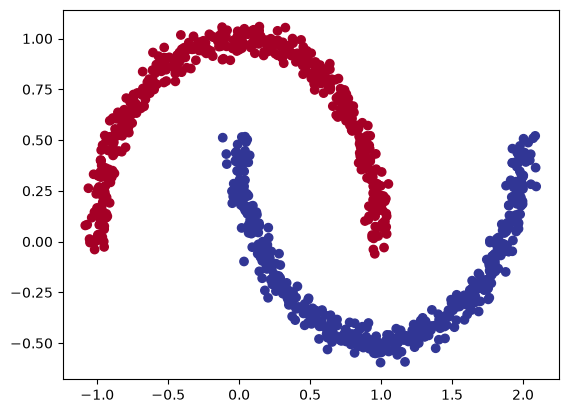

In [4]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
n_samples = 1000
X, y = make_moons(n_samples=n_samples,noise=0.04,random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [5]:
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size= 0.2, random_state=42)

In [6]:
from torch import nn

class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, X):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

In [7]:
torch.manual_seed(42)
model = CircleModel()
print(model.state_dict())

OrderedDict([('layer_1.weight', tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323],
        [ 0.5224,  0.0958],
        [ 0.3410, -0.0998],
        [ 0.5451,  0.1045],
        [-0.3301,  0.1802]])), ('layer_1.bias', tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
         0.0667, -0.6984])), ('layer_2.weight', tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
          0.0346, -0.0997],
        [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
          0.1606, -0.1927],
        [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1310,  0.1000, -0.0055,
          0.2475, -0.2247],
        [ 0.0199, -0.2158,  0.0975, -0.1089,  0.0969, -0.0659,  0.2623, -0.1874,
         -0.1886, -0.1886],
        [ 0.2844,  0.1054,  0.3043, -0.2610, -0.3137, -0.2474, -0.2127,  0.1281,
          0.1132,  0.26

In [8]:
n_of_params = 0
state_dict = model.state_dict()
n_of_params = sum(v.numel() for v in state_dict.values())
print("Number of parameters:", n_of_params)


Number of parameters: 151


In [9]:
# set up loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr = 0.1
)

In [10]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc